# Step 1 — Simulated Fraud Intelligence Dataset

In [1]:
import numpy as np
import pandas as pd
!pip install xgboost


n = 5000

fraud = pd.DataFrame({

"device_risk_score": np.random.uniform(0,1,n),

"ip_risk_score": np.random.uniform(0,1,n),

"login_velocity": np.random.randint(1,20,n),

"failed_login_ratio": np.random.uniform(0,1,n),

"geo_risk_score": np.random.uniform(0,1,n)

})

fraud["fraudulent"] = (
fraud["device_risk_score"]*2 +
fraud["ip_risk_score"]*2 +
fraud["failed_login_ratio"]*3 +
fraud["geo_risk_score"]*2
> 4
).astype(int)

fraud.head()


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,device_risk_score,ip_risk_score,login_velocity,failed_login_ratio,geo_risk_score,fraudulent
0,0.042849,0.515026,10,0.563620,0.388632,0
1,0.444780,0.131543,3,0.016503,0.863273,0
2,0.255642,0.311425,13,0.580871,0.867615,1
3,0.389779,0.173966,12,0.159787,0.039785,0
4,0.230708,0.988888,10,0.857948,0.829105,1


# Step 2 — Train XGBoost Fraud Model

In [2]:
from xgboost import XGBClassifier

from sklearn.metrics import classification_report

X = fraud.drop("fraudulent",axis=1)

y = fraud["fraudulent"]

model = XGBClassifier()

model.fit(X,y)

pred = model.predict(X)

print(classification_report(y,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1786
           1       1.00      1.00      1.00      3214

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



# Step 3 — Fraud Risk Dashboard

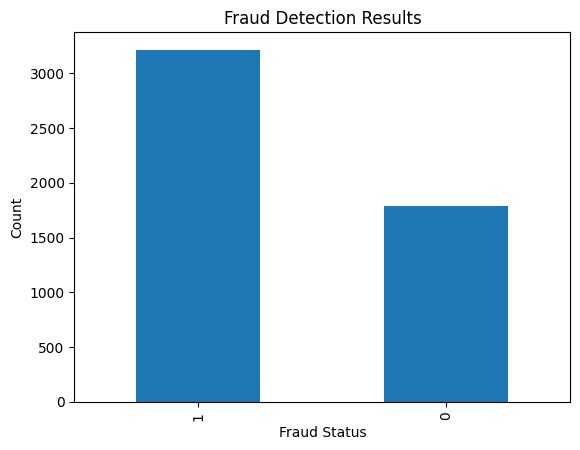

In [3]:
import matplotlib.pyplot as plt

fraud["fraudulent"].value_counts().plot(kind="bar")

plt.title("Fraud Detection Results")

plt.xlabel("Fraud Status")

plt.ylabel("Count")

plt.show()

# Step 4 — Save Model (MLOps Thinking)

In [4]:
import joblib

joblib.dump(model,"fraud_detection_model.pkl")

['fraud_detection_model.pkl']

# Simulated Real-Time Fraud Scoring

In [5]:
sample = pd.DataFrame({

"device_risk_score":[0.9],

"ip_risk_score":[0.8],

"login_velocity":[15],

"failed_login_ratio":[0.7],

"geo_risk_score":[0.9]

})

risk = model.predict_proba(sample)

print("Fraud Probability:",risk[0][1])

Fraud Probability: 0.9999999
